## Country Level Exploratory Analysis

This notebook examines the raw JKP Global Factor Data emerging markets panel
to understand the country level composition of the cross section, the monthly
firm counts per country, and the distribution of missing data across countries.
The objective is to summarize country composition, cross-sectional firm counts,
and missingness patterns using the processed column metadata file.


### 1. Setup and Configuration

In [1]:
import json
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

plt.rcParams.update({
	"mathtext.fontset": "cm", "axes.spines.top": False,
	"axes.spines.right": False, "axes.linewidth": 0.8,
	"xtick.direction": "out", "ytick.direction": "out",
	"axes.labelsize": 10, "axes.titlesize": 11,
	"xtick.labelsize": 9, "ytick.labelsize": 9,
	"figure.dpi": 150, "savefig.dpi": 300,
	"savefig.bbox": "tight",
})
figure_dir = Path("../results/country_data_summary")
figure_dir.mkdir(exist_ok = True)

data_path = Path("../data/Global Factor_EM.parquet")
metadata = Path("../data/processed/column_metadata.json")

In [2]:
id_cols = ["id", "gvkey", "iid", "eom", "excntry"]
df_ids = pd.read_parquet(data_path, columns = id_cols)

print(f"Total observations: {len(df_ids):,}")
print(f"Date range: {df_ids['eom'].min()} to {df_ids['eom'].max()}")
print(f"Unique countries: {df_ids['excntry'].nunique()}")
print(f"Unique firms (by id): {df_ids['id'].nunique():,}")

print("Countries present:")
print(sorted(df_ids["excntry"].unique()))

Total observations: 4,386,856
Date range: 1995-01-31 to 2025-12-31
Unique countries: 24
Unique firms (by id): 30,385
Countries present:
['ARE', 'BRA', 'CHL', 'CHN', 'COL', 'CZE', 'EGY', 'GRC', 'HUN', 'IDN', 'IND', 'KOR', 'KWT', 'MEX', 'MYS', 'PER', 'PHL', 'POL', 'QAT', 'SAU', 'THA', 'TUR', 'TWN', 'ZAF']


### Different Firms per Country

In [3]:
firms_per_country = (
	df_ids.groupby("excntry")["id"].nunique()
	.sort_values(ascending = False).reset_index().rename(columns = {"id": "unique_firms"})
)

total_firms = firms_per_country["unique_firms"].sum()
firms_per_country["pct_of_total"] = (firms_per_country["unique_firms"] / total_firms * 100).round(2)
firms_per_country["cumulative_pct"] = firms_per_country["pct_of_total"].cumsum().round(2)

print(f"{'Country':<10} {'Unique Firms':>14} {'% of Total':>12} {'Cumulative %':>14}")

for _, row in firms_per_country.iterrows():
	print(f"{row['excntry']:<10} {row['unique_firms']:>14,} {row['pct_of_total']:>11.2f}% {row['cumulative_pct']:>13.2f}%")
print()
print(f"{'Total':<10} {total_firms:>14,}")

Country      Unique Firms   % of Total   Cumulative %
IND                 6,829       22.47%         22.47%
CHN                 5,500       18.10%         40.57%
KOR                 4,052       13.34%         53.91%
TWN                 2,971        9.78%         63.69%
MYS                 1,617        5.32%         69.01%
POL                 1,309        4.31%         73.32%
THA                 1,265        4.16%         77.48%
IDN                 1,103        3.63%         81.11%
ZAF                 1,070        3.52%         84.63%
TUR                   742        2.44%         87.07%
GRC                   449        1.48%         88.55%
BRA                   429        1.41%         89.96%
CZE                   414        1.36%         91.32%
SAU                   411        1.35%         92.67%
PHL                   359        1.18%         93.85%
EGY                   321        1.06%         94.91%
MEX                   297        0.98%         95.89%
CHL                   294   

### Maximum Firms per Month per Country

For each country, we compute the maximum number of firms observed in any
single month. This determines the peak cross section size and is the
binding constraint for the max_firms parameter.

In [4]:
monthly_counts = (
	df_ids.groupby(["excntry", "eom"])["id"].nunique()
	.reset_index().rename(columns = {"id": "n_firms"})
)

country_monthly_stats = (
	monthly_counts.groupby("excntry")["n_firms"]
	.agg(["max", "mean", "median", "min"]).sort_values("max", ascending = False).reset_index()
)
country_monthly_stats.columns = ["excntry", "max_firms_month", "mean_firms_month", "median_firms_month", "min_firms_month"]
country_monthly_stats["mean_firms_month"] = country_monthly_stats["mean_firms_month"].round(0).astype(int)
country_monthly_stats["median_firms_month"] = country_monthly_stats["median_firms_month"].round(0).astype(int)

print(f"{'Country':<10} {'Max':>8} {'Mean':>8} {'Median':>8} {'Min':>8}")
for _, row in country_monthly_stats.iterrows():
	print(f"{row['excntry']:<10} {row['max_firms_month']:>8,} {row['mean_firms_month']:>8,} {row['median_firms_month']:>8,} {row['min_firms_month']:>8,}")

Country         Max     Mean   Median      Min
IND           5,200    2,302    2,120      229
CHN           5,106    2,148    1,814       57
KOR           2,680    1,607    1,764      201
TWN           2,290    1,351    1,528      281
MYS           1,053      845      910      386
THA             897      558      512      305
IDN             879      422      339      161
POL             826      450      442       22
TUR             587      328      308       99
ZAF             540      328      300      205
SAU             386      151      156        1
GRC             333      198      172       49
CZE             279       53       18       10
BRA             271      137      159       15
PHL             262      205      202       82
EGY             218      147      164        3
KWT             188      142      157        1
CHL             184      141      143       50
ARE             151       82       85        1
MEX             128       99       96       53
PER          

### Total Cross Section Size per Month

We compute the total number of firms across all countries for each month.
This reveals the peak cross section that max_firms must accommodate.

Peak global cross section: 21,645 firms
Mean global cross section: 11,793 firms
Median global cross section: 11,661 firms
Month of global peak: 2025-12-31
Peak within-country cross section: 5,200 firms
Mean within-country peak: 2,485 firms


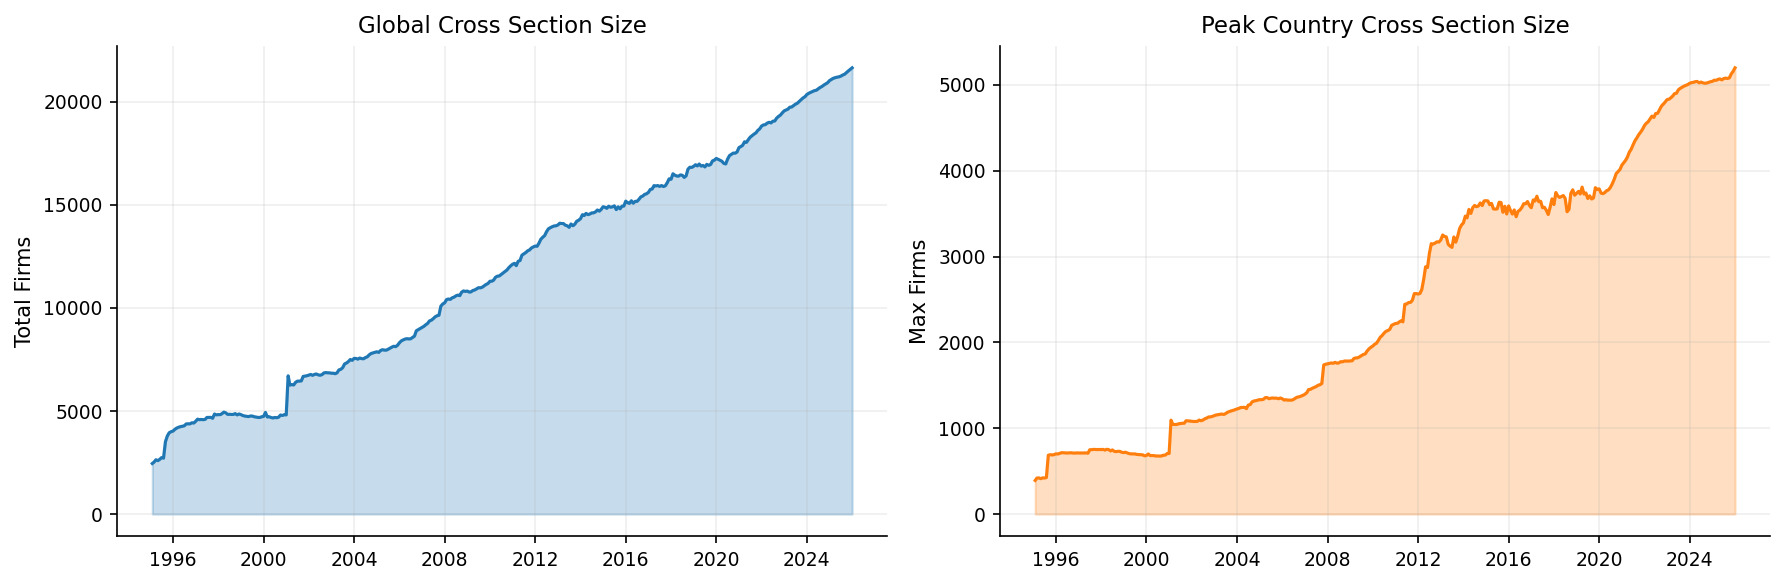

In [5]:
total_per_month = (
    monthly_counts.groupby("eom")["n_firms"].sum().reset_index().rename(columns = {"n_firms": "total_firms"})
)
max_country_per_month = (
    monthly_counts.groupby("eom")["n_firms"].max().reset_index().rename(columns = {"n_firms": "max_country_firms"})
)

print(f"Peak global cross section: {total_per_month['total_firms'].max():,} firms")
print(f"Mean global cross section: {total_per_month['total_firms'].mean():,.0f} firms")
print(f"Median global cross section: {total_per_month['total_firms'].median():,.0f} firms")
print(f"Month of global peak: {total_per_month.loc[total_per_month['total_firms'].idxmax(), 'eom']}")

print(f"Peak within-country cross section: {max_country_per_month['max_country_firms'].max():,} firms")
print(f"Mean within-country peak: {max_country_per_month['max_country_firms'].mean():,.0f} firms")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eom_dt = pd.to_datetime(total_per_month["eom"])
axes[0].plot(eom_dt, total_per_month["total_firms"], color="C0", linewidth=1.5)
axes[0].fill_between(eom_dt, total_per_month["total_firms"], alpha=0.25, color="C0")
axes[0].set_title("Global Cross Section Size")
axes[0].set_ylabel("Total Firms")
axes[0].grid(alpha=0.2)

eom_dt2 = pd.to_datetime(max_country_per_month["eom"])
axes[1].plot(eom_dt2, max_country_per_month["max_country_firms"], color="C1", linewidth=1.5)
axes[1].fill_between(eom_dt2, max_country_per_month["max_country_firms"], alpha=0.25, color="C1")
axes[1].set_title("Peak Country Cross Section Size")
axes[1].set_ylabel("Max Firms")
axes[1].grid(alpha=0.2)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(figure_dir / "country_firms.pdf")
fig.savefig(figure_dir / "country_firms.png")

### Missing Data Analysis by Country

We now load the characteristic columns alongside the country identifier to
compute per country missingness rates. The retained characteristic list comes
from `data/processed/column_metadata.json`, which is produced by the
preprocessing pipeline.


In [6]:
# Load retained characteristic columns from the processed metadata.
with open(metadata, "r") as f:
	column_metadata = json.load(f)

metadata_chars = (
	column_metadata.get("orig_char_cols")
	or column_metadata.get("all_char_cols")
	or column_metadata.get("retained_k0", []) + column_metadata.get("retained_k1", [])
)
char_bases = list(dict.fromkeys(metadata_chars))

if not char_bases:
	raise ValueError(f"No characteristic columns found in {metadata}")

chars_in_raw = char_bases
read_cols = ["id", "eom", "excntry"] + chars_in_raw

print(f"Characteristics to analyse: {len(chars_in_raw)}")
print(f"Reading {len(read_cols)} columns from raw data...")

try:
	df_miss = pd.read_parquet(data_path, columns = read_cols)
except (KeyError, ValueError) as exc:
	raise ValueError(
		"The processed metadata contains characteristic columns that were not "
		"found in the raw parquet file. Regenerate data/processed/column_metadata.json "
		"from the same raw data file, or inspect the metadata column lists."
	) from exc

print(f"Loaded: {len(df_miss):,} rows")


Characteristics to analyse: 152
Reading 155 columns from raw data...
Loaded: 4,386,856 rows


#### Mean Missingness Rate per Country

In [7]:
# Compute per-row missing fraction across characteristics
char_data = df_miss[chars_in_raw]
df_miss["miss_frac"] = char_data.isnull().sum(axis = 1) / len(chars_in_raw)
country_miss = (df_miss.groupby("excntry")["miss_frac"].agg(["mean", "median", "std"]).sort_values("mean", ascending = False).reset_index())
country_miss.columns = ["excntry", "mean_miss_rate", "median_miss_rate", "std_miss_rate"]

print(f"{'Country':<10} {'Mean Miss %':>12} {'Median Miss %':>14} {'Std':>8}")
print()
for _, row in country_miss.iterrows():
	print(
		f"{row['excntry']:<10}{row['mean_miss_rate']*100:>11.2f}%{row['median_miss_rate']*100:>13.2f}%{row['std_miss_rate']:>8.4f}"
	)

Country     Mean Miss %  Median Miss %      Std

CZE             61.42%        75.00%  0.3335
HUN             34.14%        15.79%  0.3554
KOR             28.75%         5.92%  0.3231
ZAF             23.64%         8.55%  0.3043
PER             22.80%        16.45%  0.2415
EGY             22.66%         8.55%  0.2835
COL             21.77%        15.79%  0.2619
GRC             20.43%         7.24%  0.2731
CHL             18.72%        15.13%  0.2184
KWT             17.09%        10.53%  0.1998
PHL             17.00%         8.55%  0.2238
ARE             16.75%        12.50%  0.1814
TUR             16.02%         2.63%  0.2580
MEX             13.99%         3.95%  0.2207
IND             13.56%         3.29%  0.2098
IDN             13.47%         6.58%  0.2034
POL             12.75%         3.29%  0.2026
THA             12.61%         2.63%  0.2243
QAT             12.13%         5.26%  0.1776
SAU             10.64%         3.29%  0.1701
BRA             10.31%         2.63%  0.1847
TWN   

#### Proportion of Heavily Missing Observations per Country

We define a heavily missing observation as one where more than one third
of characteristics are null, consistent with the exclusion threshold
discussed in the proposal methodology.

In [8]:
df_miss["heavily_missing"] = df_miss["miss_frac"] > (1.0 / 3.0)

heavy_miss_by_country = (
	df_miss.groupby("excntry")
	.agg(total_obs = ("id", "count"), heavy_miss_obs = ("heavily_missing", "sum"),
	).reset_index()
)
heavy_miss_by_country["heavy_miss_pct"] = (
	heavy_miss_by_country["heavy_miss_obs"] / heavy_miss_by_country["total_obs"] * 100
).round(2)
heavy_miss_by_country = heavy_miss_by_country.sort_values("heavy_miss_pct", ascending = False)

print(f"{'Country':<10} {'Total Obs':>12} {'Heavy Miss Obs':>16} {'Heavy Miss %':>14}")
print()
for _, row in heavy_miss_by_country.iterrows():
	print(
		f"{row['excntry']:<10} {int(row['total_obs']):>12,}{int(row['heavy_miss_obs']):>16,} {row['heavy_miss_pct']:>13.2f}%"
	)

Country       Total Obs   Heavy Miss Obs   Heavy Miss %

CZE              19,758          14,367         72.71%
HUN              14,550           6,175         42.44%
KOR             597,768         238,343         39.87%
ZAF             121,965          31,141         25.53%
EGY              51,366          12,586         24.50%
GRC              73,634          17,128         23.26%
COL              13,846           2,633         19.02%
PER              26,728           4,905         18.35%
TUR             121,901          21,974         18.03%
ARE              24,356           3,751         15.40%
PHL              76,146          11,487         15.09%
KWT              42,460           6,217         14.64%
CHL              52,277           7,578         14.50%
IND             856,338         115,877         13.53%
THA             207,427          26,141         12.60%
POL             167,357          19,666         11.75%
MEX              36,936           3,975         10.76%
IDN     

In [9]:
# Merge country stats together into one inspection table.
summary = firms_per_country.merge(country_monthly_stats, on = "excntry")
summary = summary.merge(country_miss[["excntry", "mean_miss_rate"]], on = "excntry")
summary = summary.merge(
	heavy_miss_by_country[["excntry", "heavy_miss_pct"]], on = "excntry"
)
summary = summary.sort_values("unique_firms", ascending = False)

summary_display = summary.copy()
summary_display["mean_miss_pct"] = (summary_display["mean_miss_rate"] * 100).round(2)
summary_display = summary_display.drop(columns = ["mean_miss_rate"])
summary_display = summary_display[
	[
		"excntry", "unique_firms", "pct_of_total", "cumulative_pct",
		"max_firms_month", "mean_firms_month", "median_firms_month",
		"min_firms_month", "mean_miss_pct", "heavy_miss_pct",
	]
]

print("Country-level composition and missingness summary")
display(summary_display)


Country-level composition and missingness summary


,excntry,unique_firms,pct_of_total,cumulative_pct,max_firms_month,mean_firms_month,median_firms_month,min_firms_month,mean_miss_pct,heavy_miss_pct
0,IND,6829,22.47,22.47,5200,2302,2120,229,13.56,13.53
1,CHN,5500,18.10,40.57,5106,2148,1814,57,3.53,1.28
2,KOR,4052,13.34,53.91,2680,1607,1764,201,28.75,39.87
3,TWN,2971,9.78,63.69,2290,1351,1528,281,9.32,10.21
4,MYS,1617,5.32,69.01,1053,845,910,386,8.87,5.95
5,POL,1309,4.31,73.32,826,450,442,22,12.75,11.75
6,THA,1265,4.16,77.48,897,558,512,305,12.61,12.60
7,IDN,1103,3.63,81.11,879,422,339,161,13.47,10.65
8,ZAF,1070,3.52,84.63,540,328,300,205,23.64,25.53
9,TUR,742,2.44,87.07,587,328,308,99,16.02,18.03


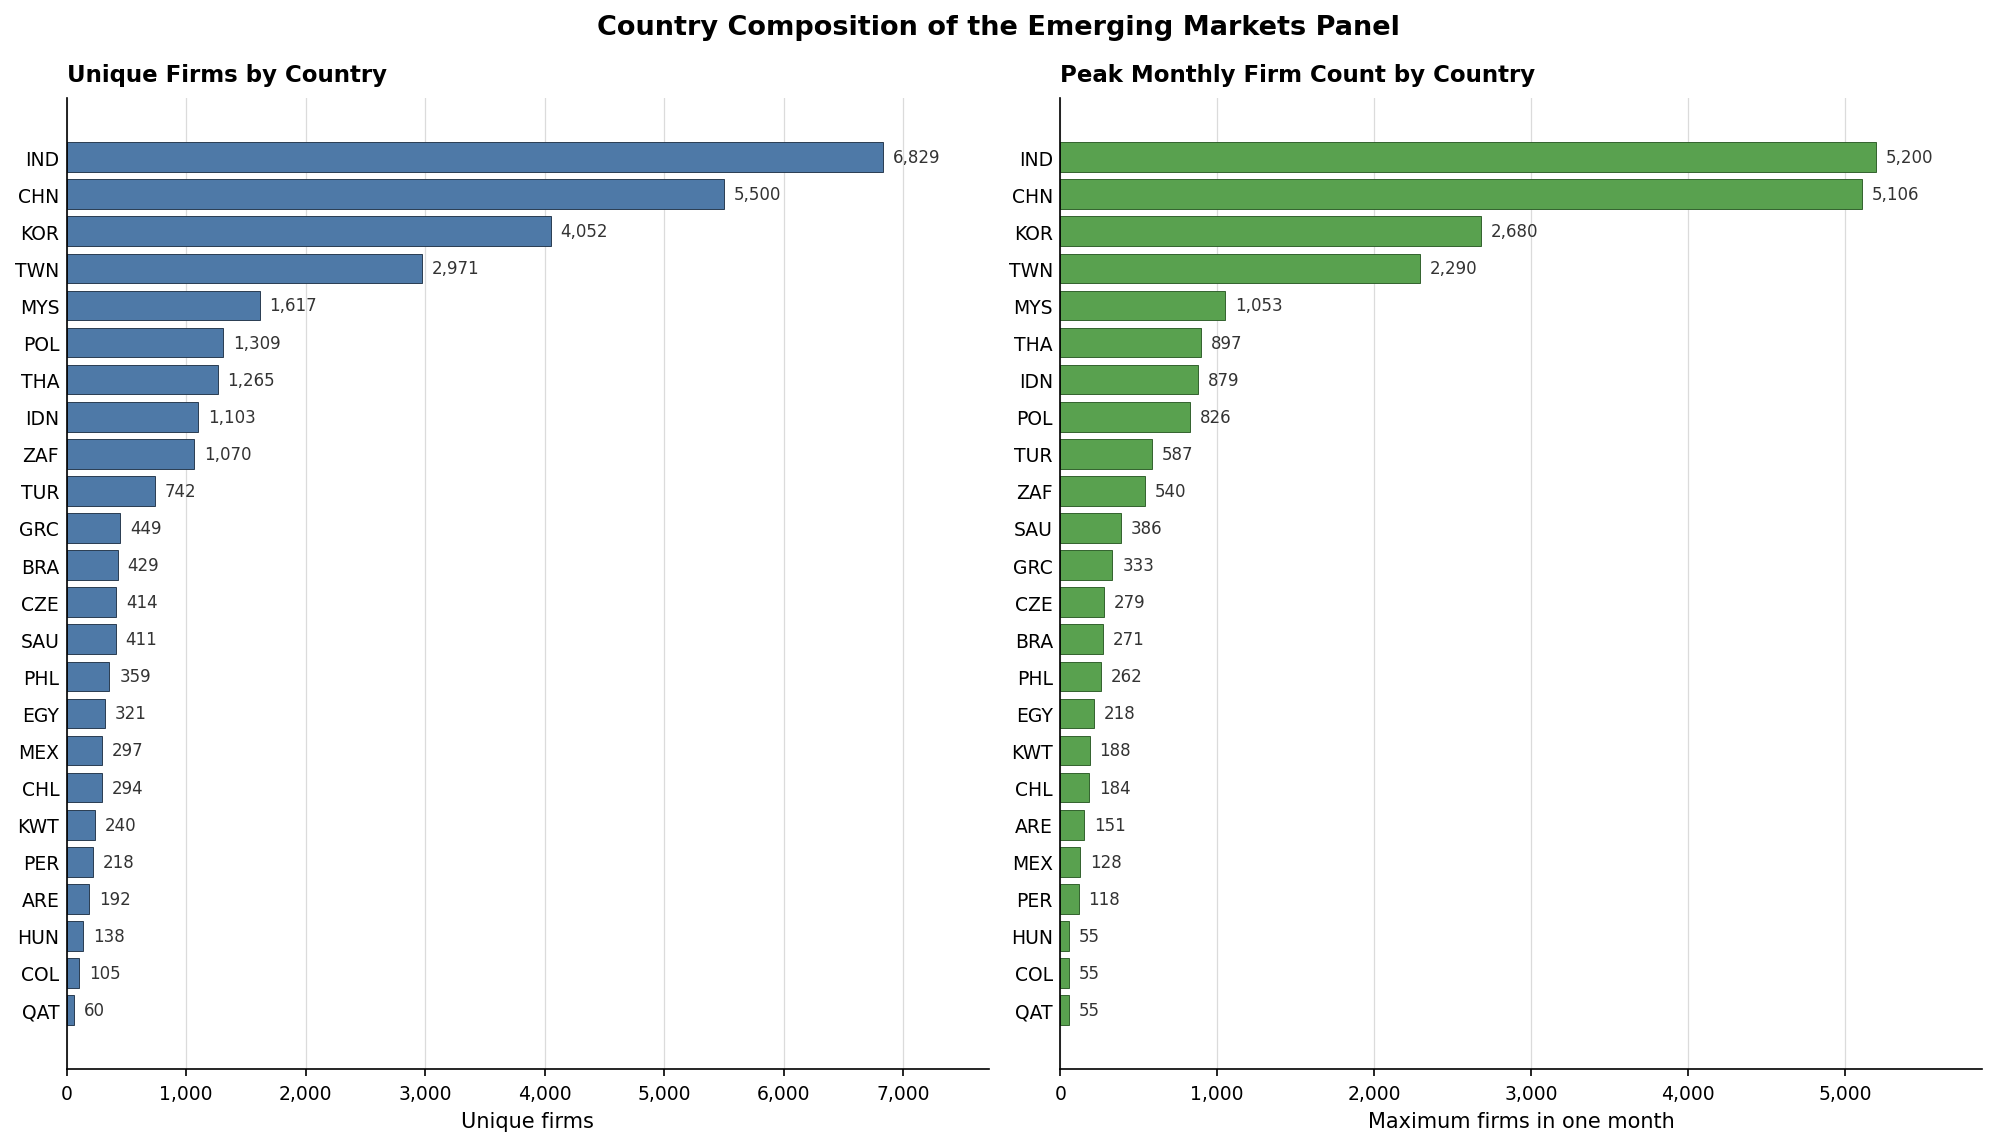

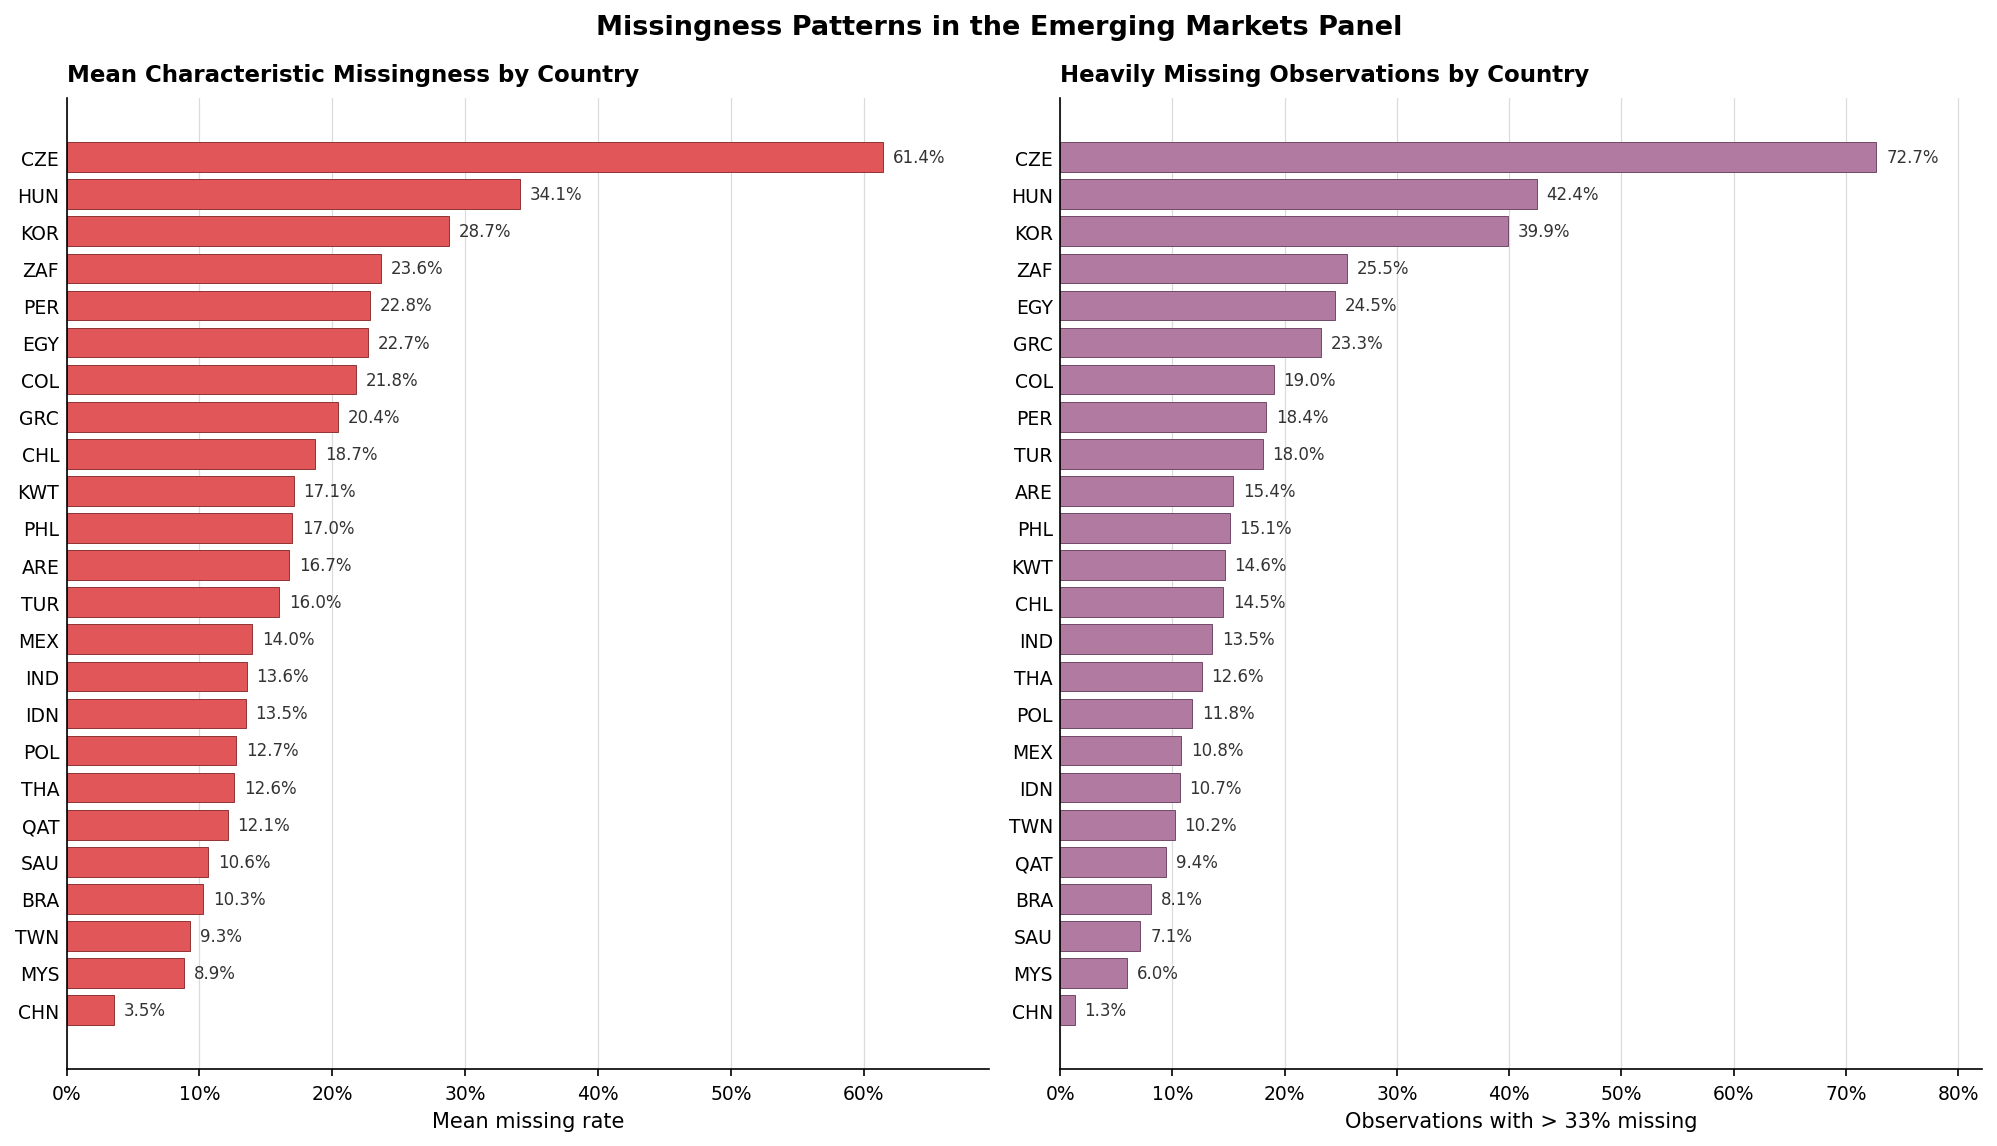

In [10]:
bar_color = "#4E79A7"
bar_edge = "#26384D"
grid_color = "#D0D0D0"


def format_bar_axis(ax, xlabel, title, percent = False):
	ax.set_xlabel(xlabel)
	ax.set_title(title, loc = "left", pad = 8, fontweight = "bold")
	ax.grid(axis = "x", color = grid_color, linewidth = 0.6, alpha = 0.75)
	ax.set_axisbelow(True)
	if percent:
		ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax = 100, decimals = 0))
	else:
		ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
	ax.tick_params(axis = "y", length = 0)


def add_bar_end_labels(ax, values, percent = False):
	xmax = max(values) if len(values) else 0
	offset = xmax * 0.012 if xmax else 0.1
	for patch, value in zip(ax.patches, values):
		label = f"{value:.1f}%" if percent else f"{value:,.0f}"
		ax.text(patch.get_width() + offset, patch.get_y() + patch.get_height() / 2,
			label, va = "center", ha = "left", fontsize = 8, color = "#333333",
		)
	ax.set_xlim(right = xmax * 1.13 if xmax else 1)


# Figure 1: country-level firm counts.
fig, axes = plt.subplots(1, 2, figsize = (13.2, 7.2), constrained_layout = True)

ax = axes[0]
plot_data = firms_per_country.sort_values("unique_firms", ascending = True)
values = plot_data["unique_firms"].to_numpy()
ax.barh(plot_data["excntry"], values, color = bar_color, edgecolor = bar_edge, linewidth = 0.45)
format_bar_axis(ax, "Unique firms", "Unique Firms by Country")
add_bar_end_labels(ax, values)

ax = axes[1]
plot_data = country_monthly_stats.sort_values("max_firms_month", ascending = True)
values = plot_data["max_firms_month"].to_numpy()
ax.barh(plot_data["excntry"], values, color = "#59A14F", edgecolor = "#2F5E2A", linewidth = 0.45)
format_bar_axis(ax, "Maximum firms in one month", "Peak Monthly Firm Count by Country")
add_bar_end_labels(ax, values)

fig.suptitle("Country Composition of the Emerging Markets Panel", fontsize = 13, fontweight = "bold", y = 1.04)
fig.savefig(figure_dir / "country_firm_counts.pdf")
fig.savefig(figure_dir / "country_firm_counts.png")
plt.show()


# Figure 2: country-level missingness.
fig, axes = plt.subplots(1, 2, figsize = (13.2, 7.2), constrained_layout = True)

ax = axes[0]
plot_data = country_miss.sort_values("mean_miss_rate", ascending = True)
values = (plot_data["mean_miss_rate"] * 100).to_numpy()
ax.barh(plot_data["excntry"], values, color = "#E15759", edgecolor = "#8C2F31", linewidth = 0.45)
format_bar_axis(ax, "Mean missing rate", "Mean Characteristic Missingness by Country", percent = True)
add_bar_end_labels(ax, values, percent = True)

ax = axes[1]
plot_data = heavy_miss_by_country.sort_values("heavy_miss_pct", ascending = True)
values = plot_data["heavy_miss_pct"].to_numpy()
ax.barh(plot_data["excntry"], values, color = "#B07AA1", edgecolor = "#6D4564", linewidth = 0.45)
format_bar_axis(ax, "Observations with > 33% missing", "Heavily Missing Observations by Country", percent = True)
add_bar_end_labels(ax, values, percent = True)

fig.suptitle("Missingness Patterns in the Emerging Markets Panel", fontsize = 13, fontweight = "bold", y = 1.04)
fig.savefig(figure_dir / "country_missingness.pdf")
fig.savefig(figure_dir / "country_missingness.png")
plt.show()
